<a href="https://colab.research.google.com/github/EsserMishelle/short-term-stock-forecast/blob/main/06_final_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Model Comparasion
## NVDA Short-Term Forecasting Study

This notebook consolidates performance results from all modeling approaches:
- Naive Baseline + Drift Naive Models
- ARIMA Model
- Prophet Model
- Price-Based NVDA Only, Cross-Asset, Lasso Linear Regression Models
- Return-Based Simple and Random Forest Models

Performance is evaluated using out-of-sample RMSE across forecast horizons.

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Define folder path within the drive
folder_path = '/content/drive/MyDrive/stocks'
os.makedirs(folder_path, exist_ok=True)

Mounted at /content/drive


## Load Model Performance Results

All performance metrics saved from prior notebooks are loaded here to for evaluation.

In [ ]:
naive_baseline_df = pd.read_csv(os.path.join(folder_path, "naive_baseline_results.csv"))
naive_drift_df = pd.read_csv(os.path.join(folder_path, "naive_drift_results.csv"))
arima_df = pd.read_csv(os.path.join(folder_path, "arima_results.csv"))
prophet_df = pd.read_csv(os.path.join(folder_path, "prophet_results.csv"))

price_lr_uni_df = pd.read_csv(os.path.join(folder_path, "price_based_lr_uni_results.csv"))
price_lr_mul_df = pd.read_csv(os.path.join(folder_path, "price_based_lr_mul_results.csv"))
price_lasso_df = pd.read_csv(os.path.join(folder_path, "price_based_lasso_results.csv"))

ret_lr_df = pd.read_csv(os.path.join(folder_path, "return_simple_lr_results.csv"))
ret_rf_df = pd.read_csv(os.path.join(folder_path, "return_rf_results.csv"))

In [ ]:
naive_baseline_df['Model'] = 'Naive_Baseline'
naive_drift_df["Model"] = "Naive_Drift"
arima_df["Model"] = "ARIMA"
prophet_df["Model"] = "Prophet"

price_lr_uni_df["Model"] = "Price_LR_Univariate"
price_lr_mul_df["Model"] = "Price_LR_Multivariate"
price_lasso_df["Model"] = "Price_Lasso"

ret_lr_df["Model"] = "Return_LR"
ret_rf_df["Model"] = "Return_RF"

In [ ]:
# Make sure all models have same column name for comparison
naive_baseline_df["Metric"] = naive_baseline_df["Test_RMSE"]
naive_drift_df["Metric"] = naive_drift_df["Test_RMSE"]
price_lr_uni_df["Metric"] = price_lr_uni_df["Test_RMSE"]
price_lr_mul_df["Metric"] = price_lr_mul_df["Test_RMSE"]
price_lasso_df["Metric"] = price_lasso_df["Test_RMSE"]

ret_lr_df["Metric"] = ret_lr_df["Price_RMSE"]
ret_rf_df["Metric"] = ret_rf_df["Price_RMSE"]

arima_df["Metric"] = arima_df["Test_RMSE"]
prophet_df["Metric"] = prophet_df["Test_RMSE"]

In [ ]:
horizon = [1, 5, 10, 20, 30]

### Table 1 — Forecast Accuracy Across Models and Horizons (1–30 Days)

The following models are evaluated across multiple forecast horizons:
Naive, Naive with Drift, Price-based Linear Regression models, Lasso,
and Return-based machine learning models.

In [ ]:
cols = ["Model", "Horizon", "Metric"]

ml_dfs = [
    naive_baseline_df[cols],
    naive_drift_df[cols],
    price_lr_uni_df[cols],
    price_lr_mul_df[cols],
    price_lasso_df[cols],
    ret_lr_df[cols],
    ret_rf_df[cols],
]

all_models_df = pd.concat(ml_dfs, ignore_index=True)

pivot_ml = all_models_df.pivot(
    index="Horizon",
    columns="Model",
    values="Metric"
)
display(pivot_ml.round(2))

Model,Naive_Baseline,Naive_Drift,Price_LR_Multivariate,Price_LR_Univariate,Price_Lasso,Return_LR,Return_RF
Horizon,,,,,,,
1,3.89,3.88,4.87,5.18,5.61,3.89,3.95
5,8.21,8.15,8.31,8.37,8.37,8.25,8.53
10,10.91,10.73,11.84,10.60,10.77,11.05,11.12
20,15.07,14.54,15.92,13.71,14.48,15.38,17.25
30,19.85,18.75,17.57,16.98,16.05,19.69,22.22


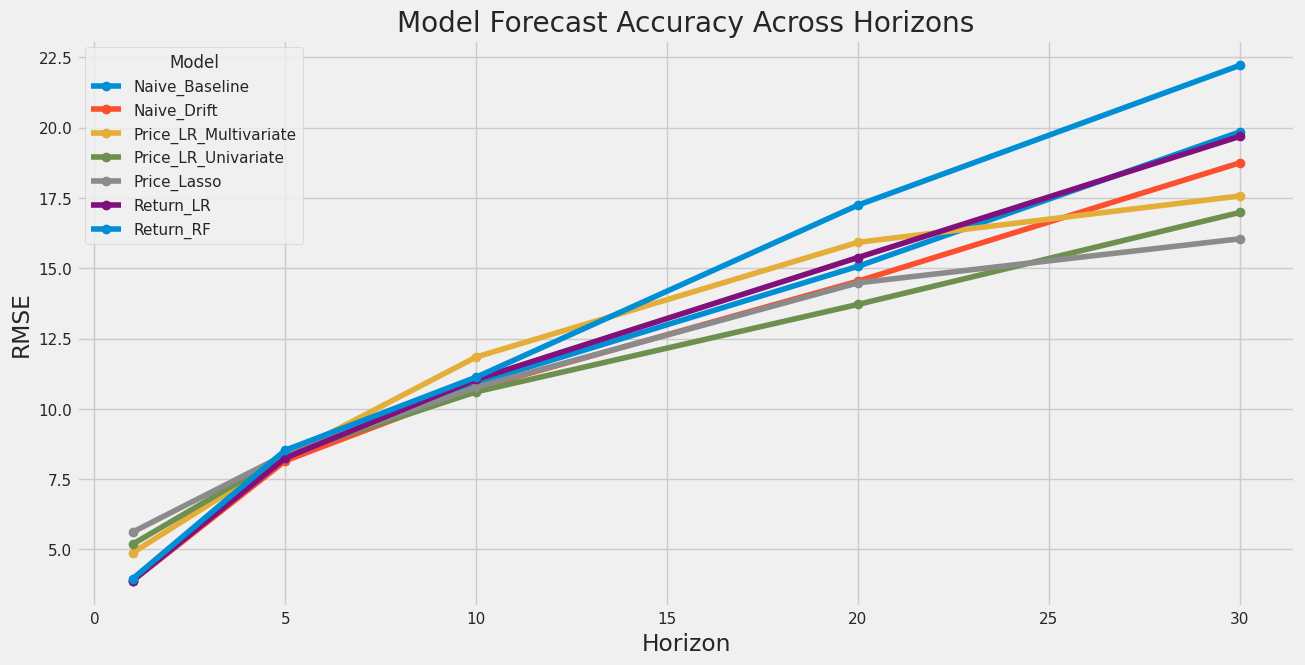

In [ ]:
ax = pivot_ml.plot(marker='o', figsize=(14,7))

plt.ylabel("RMSE")
plt.title("Model Forecast Accuracy Across Horizons")
plt.grid(True)

# extract the colors used by the lines
line_colors = {line.get_label(): line.get_color() for line in ax.get_lines()}

### Interpretation of Multi-Horizon Forecast Results

#### The table above compares forecast accuracy across models and prediction horizons using RMSE. Several patterns emerge across different forecast horizons.

### Short horizons (1–5 days)

#### The Naive baseline, Naive-Drift, and Return Linear Regression models perform best, indicating that very short-term price movements are difficult to predict beyond the current price level. In this range, machine learning models do not outperform the simple random-walk assumption.

### Intermediate horizons (5–10 days)
#### Performance differences across models remain small. Both price-based and return-based approaches produce similar errors, suggesting that short-term equity movements remain largely unpredictable.

### Longer horizons (20–30 days)
#### Price-based models begin to outperform the naive baselines. In particular, the price-based Lasso regression model achieves the lowest RMSE at the 30-day horizon, followed by the univariate price-based linear regression model.

### Return-based models
#### Return-based models perform less consistently. While the simple return-based linear regression performs among the top models across several horizons, the Random Forest model shows the largest error growth at longer horizons.

### Relationship between Return LR and the Naive baseline
#### Interestingly, the return-based linear regression model produces nearly identical RMSE values to the naive baseline across horizons. This occurs because predicting returns close to zero effectively results in a forecast equivalent to the random-walk assumption, where the future price is approximately equal to the current price.

#### Overall, the results highlight a well-known characteristic of financial markets: simple models often perform competitively at short horizons, while engineered features and regularization applied to price-based models can provide modest improvements at longer horizons.




### Table 2 — Consolidated Long-Horizon Forecast Comparison (30-Day RMSE)

ARIMA and Prophet models are evaluated only for the 30-day forecast horizon.
To enable comparison, the 30-day RMSE from all models is used for the chart below.

In [ ]:
ml_30 = all_models_df[all_models_df["Horizon"] == 30]

arima_30 = arima_df[["Model", "Metric"]]
prophet_30 = prophet_df[["Model", "Metric"]]

long_horizon_df = pd.concat([
    ml_30[["Model","Metric"]],
    arima_30,
    prophet_30
], ignore_index=True)

display(long_horizon_df.round(2))

,Model,Metric
0,Naive_Baseline,19.85
1,Naive_Drift,18.75
2,Price_LR_Univariate,16.98
3,Price_LR_Multivariate,17.57
4,Price_Lasso,16.05
5,Return_LR,19.69
6,Return_RF,22.22
7,ARIMA,31.94
8,Prophet,31.80


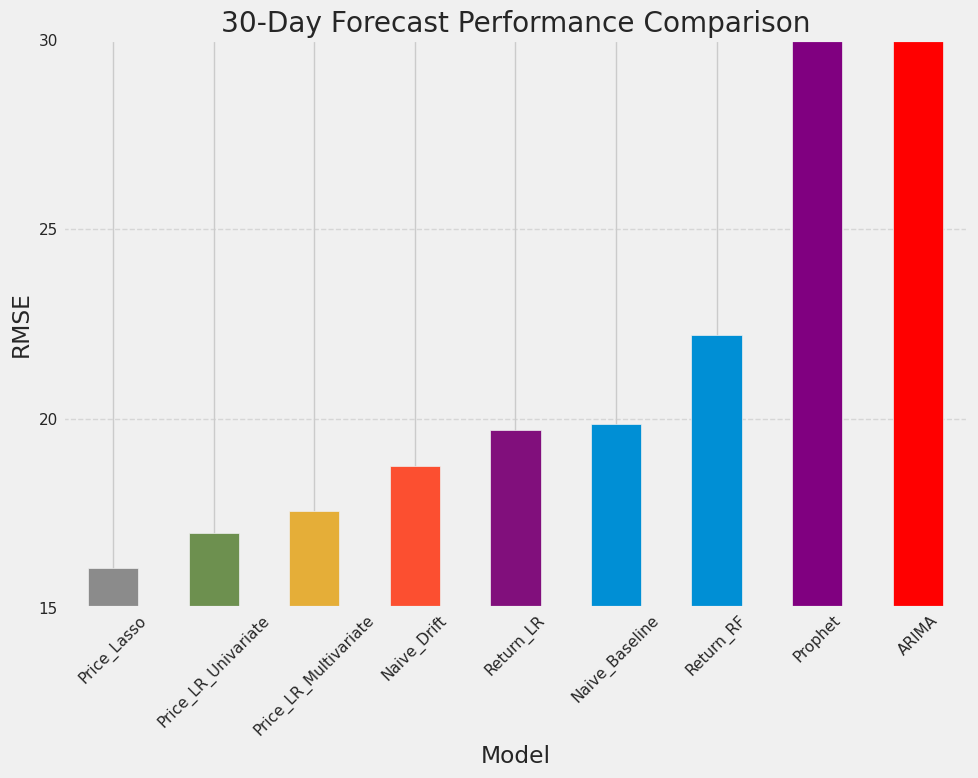

In [ ]:
long_horizon_df_sorted = long_horizon_df.sort_values("Metric")

fallback_colors = {
    "ARIMA": "red",
    "Prophet": "purple"
}

bar_colors = [
    line_colors.get(m, fallback_colors.get(m, "gray"))
    for m in long_horizon_df_sorted["Model"]
]

long_horizon_df_sorted.plot(
    kind="bar",
    x="Model",
    y="Metric",
    legend=False,
    figsize=(10,8),
    color=bar_colors
)

plt.ylabel("RMSE")
plt.title("30-Day Forecast Performance Comparison")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle= '--', alpha=.7)
plt.ylim(15,25)
plt.yticks(range(15, 35, 5))

plt.tight_layout()

### Long-Horizon Forecast Comparison

#### The chart above compares model performance specifically at the 30-day forecast horizon. Price-based models achieve the lowest prediction error, with Lasso regression producing the best performance, followed by the univariate and multivariate linear regression models. These results suggest that incorporating lagged price features and applying regularization can help capture longer-term structure in the data.

#### Baseline models remain competitive, with the Naive-Drift model performing better than the standard Naive baseline, indicating that incorporating a simple trend component improves long-horizon forecasts.

#### Return-based models perform less effectively at this horizon. While the return-based linear regression model remains competitive with the naive baseline, the Random Forest model exhibits larger prediction errors, suggesting that increased model complexity does not necessarily translate into better forecasting performance for financial time series.

#### Finally, traditional time-series models such as ARIMA and Prophet produce the highest RMSE values in this experiment, indicating that in this dataset they do not outperform simpler regression-based approaches for long-horizon forecasting.

### **Project Summary**

This project explored multiple approaches for forecasting short-term stock prices using NVIDIA (NVDA) data and related market signals. The analysis evaluated traditional baselines, statistical time-series models, and machine learning approaches across multiple forecast horizons.

Several key insights emerge. First, simple baseline models are difficult to outperform at very short horizons, reinforcing the well-known random-walk behavior of financial prices. Second, price-based regression models outperform return-based models, suggesting that modeling price levels with engineered lag features captures more useful structure than predicting returns directly. Third, regularization improves long-horizon performance, with Lasso regression producing the most accurate 30-day forecasts among the tested models.

Overall, the results highlight the inherent difficulty of predicting short-term equity movements. While more complex models can provide modest improvements at longer horizons, simple models remain strong benchmarks in financial forecasting tasks.